In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
PROJECT_ROOT = Path("..")

BROWSE_IMAGE = PROJECT_ROOT / (
    "data/raw/tmc2/baseline/"
    "browse/calibrated/20210401/"
    "ch2_ohr_ncp_20210401T2357376656_b_brw_d18.png"
)

print(BROWSE_IMAGE)

../data/raw/tmc2/baseline/browse/calibrated/20210401/ch2_ohr_ncp_20210401T2357376656_b_brw_d18.png


In [4]:
img = cv2.imread(str(BROWSE_IMAGE), cv2.IMREAD_UNCHANGED)

print("Shape:", img.shape)
print("Dtype:", img.dtype)

Shape: (9014, 1200)
Dtype: uint8


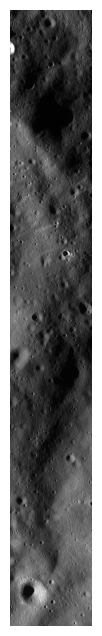

In [5]:
plt.figure(figsize=(12,8))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
DATA_ROOT = Path("../data/raw/tmc2/baseline")

img_path = (
    DATA_ROOT
    / "data"
    / "calibrated"
    / "20210401"
    / "ch2_ohr_ncp_20210401T2357376656_d_img_d18.img"
)

xml_path = img_path.with_suffix(".xml")

print("IMG exists:", img_path.exists())
print("XML exists:", xml_path.exists())
print("IMG:", img_path)

IMG exists: True
XML exists: True
IMG: ../data/raw/tmc2/baseline/data/calibrated/20210401/ch2_ohr_ncp_20210401T2357376656_d_img_d18.img


In [9]:
import xml.etree.ElementTree as ET

tree = ET.parse(xml_path)
root = tree.getroot()

# Print all XML elements containing useful image metadata
for elem in root.iter():
    tag = elem.tag.split("}")[-1]  # Remove XML namespace
    if elem.text and elem.text.strip():
        if tag in [
            "file_name",
            "file_size",
            "data_type",
            "axis_name",
            "elements",
            "pixel_resolution",
            "projection",
            "area"
        ]:
            print(f"{tag}: {elem.text.strip()}")

pixel_resolution: 0.26
projection: Selenographic
area: Equatorial
file_name: ch2_ohr_ncp_20210401T2357376656_d_img_d18.img
file_size: 1081776000
data_type: UnsignedByte
axis_name: Line
elements: 90148
axis_name: Sample
elements: 12000


In [10]:
ns = {
    "pds": "http://pds.nasa.gov/pds4/pds/v1"
}

axes = root.findall(".//pds:Axis_Array", ns)

dimensions = {}

for axis in axes:
    name = axis.find("pds:axis_name", ns).text
    elements = int(axis.find("pds:elements", ns).text)

    dimensions[name] = elements

print(dimensions)

{'Line': 90148, 'Sample': 12000}


In [11]:
lines = dimensions["Line"]
samples = dimensions["Sample"]

image = np.memmap(
    img_path,
    dtype=np.uint16,
    mode="r",
    shape=(lines, samples)
)

print(image.shape)
print(image.dtype)

ValueError: mmap length is greater than file size

In [12]:
patch = image[50000:51000, 1500:2500]

print(patch.shape)
print("Min:", patch.min())
print("Max:", patch.max())
print("Mean:", patch.mean())

NameError: name 'image' is not defined

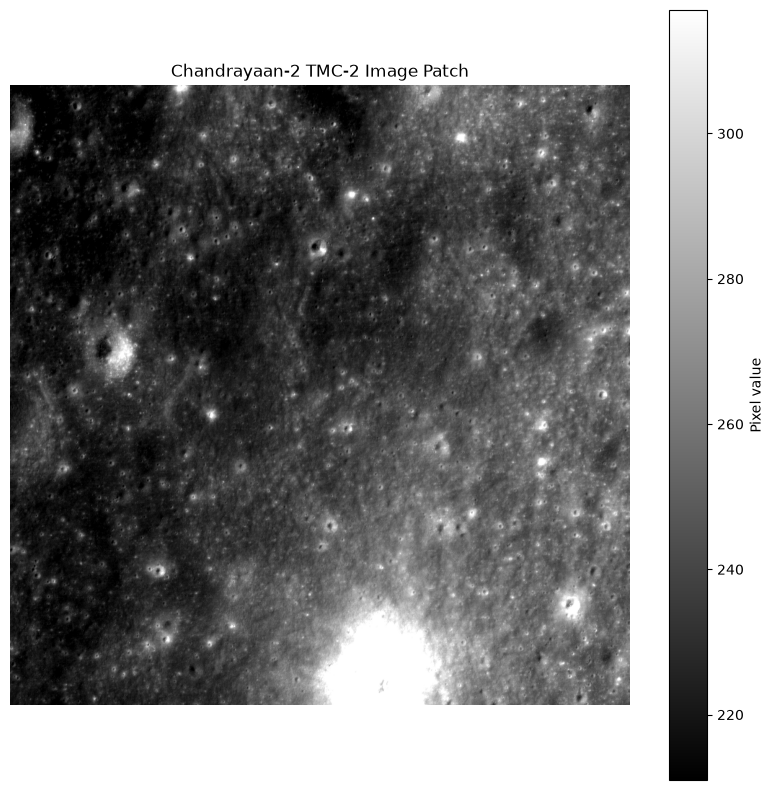

In [41]:
plt.figure(figsize=(10, 10))

plt.imshow(
    patch,
    cmap="gray",
    vmin=np.percentile(patch, 2),
    vmax=np.percentile(patch, 98)
)

plt.colorbar(label="Pixel value")
plt.title("Chandrayaan-2 TMC-2 Image Patch")
plt.axis("off")

plt.show()

In [42]:
vmin=np.percentile(patch, 2)
vmax=np.percentile(patch, 98)


In [43]:
print("Shape:", image.shape)
print("Dtype:", image.dtype)
print("Min:", image.min())
print("Max:", image.max())
print("Mean:", image.mean())
print("Std:", image.std())

Shape: (148108, 4000)
Dtype: uint16
Min: 0
Max: 806
Mean: 244.7517743977368
Std: 38.30185112072792


In [44]:
img = cv2.imread(str(BROWSE_IMAGE), cv2.IMREAD_UNCHANGED)

print("Shape:", img.shape)
print("Dtype:", img.dtype)

Shape: (14811, 400)
Dtype: uint8


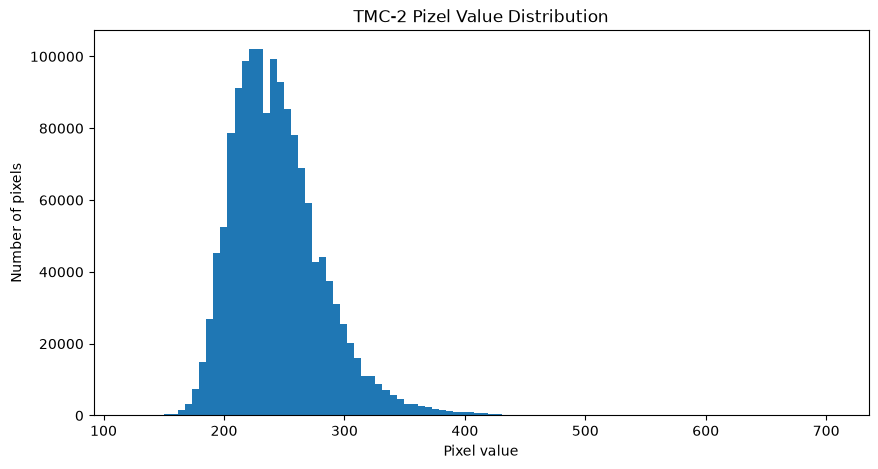

Zero pixels: 0
Zero percentage: 0.0


In [45]:
sampled = image[::20, ::20]

plt.figure(figsize = (10,5))
plt.hist(
    sampled.ravel(),
    bins=100
)

plt.title("TMC-2 Pizel Value Distribution")
plt.xlabel("Pixel value")
plt.ylabel("Number of pixels")

plt.show()

print("Zero pixels:", np.sum(sampled ==0))
print("Zero percentage:", 100*np.mean(sampled ==0))

In [46]:
for p in [0, 1, 2, 5, 25, 50, 75, 95, 98, 99, 100]:
    print(f"{p:>3}%: {np.percentile(sampled, p):.2f}")

  0%: 121.00
  1%: 180.00
  2%: 186.00
  5%: 194.00
 25%: 217.00
 50%: 239.00
 75%: 265.00
 95%: 313.00
 98%: 341.00
 99%: 364.00
100%: 706.00


In [47]:
geometry_dir = (
    DATA_ROOT
    / "geometry"
    / "calibrated"
    / "20260813"
)

csv_path = next(geometry_dir.glob("*.csv"))
geom_xml_path = next(geometry_dir.glob("*.xml"))

print("CSV:", csv_path)
print("XML:", geom_xml_path)

CSV: ../data/raw/tmc2/ch2_tmc_ncn_20260813T0627378557_d_img_d18/geometry/calibrated/20260813/ch2_tmc_ncn_20260813T0627378557_g_grd_d18.csv
XML: ../data/raw/tmc2/ch2_tmc_ncn_20260813T0627378557_d_img_d18/geometry/calibrated/20260813/ch2_tmc_ncn_20260813T0627378557_g_grd_d18.xml


In [54]:
import pandas as pd

geo_df = pd.read_csv(csv_path)

print("Shape:", geo_df.shape)
display(geo_df.head())
print("\nColumns:")
print(geo_df.columns.tolist())

Shape: (60803, 4)


,Longitude,Latitude,Pixel,Scan
0,142.707917,-3.752311,0,0
1,142.689820,-3.751710,100,0
2,142.671725,-3.751110,200,0
3,142.653631,-3.750508,300,0
4,142.635538,-3.749907,400,0



Columns:
['Longitude', 'Latitude', 'Pixel', 'Scan']


In [55]:
print("Pixel range:")
print(geo_df["Pixel"].min(), geo_df["Pixel"].max())

print("\nScan range:")
print(geo_df["Scan"].min(), geo_df["Scan"].max())

print("\nUnique pixels:")
print(sorted(geo_df["Pixel"].unique())[:20])

print("\nRows for Pixel = 0:")
print(geo_df[geo_df["Pixel"] == 0].head(10))

Pixel range:
0 3999

Scan range:
0 148107

Unique pixels:
[np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900)]

Rows for Pixel = 0:
      Longitude  Latitude  Pixel  Scan
0    142.707917 -3.752311      0     0
41   142.707307 -3.768545      0   100
82   142.706732 -3.784781      0   200
123  142.706122 -3.801003      0   300
164  142.705492 -3.817309      0   400
205  142.704900 -3.833553      0   500
246  142.704261 -3.849815      0   600
287  142.703689 -3.866036      0   700
328  142.703047 -3.882335      0   800
369  142.702462 -3.898568      0   900


In [56]:
print("Longitude range:")
print(
    geometry_df["Longitude"].min(),
    geometry_df["Longitude"].max()
)

print("\nLatitude range:")
print(
    geometry_df["Latitude"].min(),
    geometry_df["Latitude"].max()
)

print("\nCorner coordinates:")
for scan, pixel in [
    (0, 0),
    (0, 3999),
    (148107, 0),
    (148107, 3999)
]:
    row = geometry_df[
        (geometry_df["Scan"] == scan) &
        (geometry_df["Pixel"] == pixel)
    ]

    print(f"\nScan={scan}, Pixel={pixel}")
    display(row)

Longitude range:
140.956267 142.707917

Latitude range:
-27.8666943 -3.7280291

Corner coordinates:

Scan=0, Pixel=0


,Longitude,Latitude,Pixel,Scan
0,142.707917,-3.752311,0,0



Scan=0, Pixel=3999


,Longitude,Latitude,Pixel,Scan
40,141.984547,-3.728029,3999,0



Scan=148107, Pixel=0


,Longitude,Latitude,Pixel,Scan
60762,141.749847,-27.866694,0,148107



Scan=148107, Pixel=3999


,Longitude,Latitude,Pixel,Scan
60802,140.956267,-27.840021,3999,148107
